#Exercícios para entregar 6

###Aluno: Katlyn Ribeiro Almeida           
###Nusp:14586070

In [53]:
#acredito que separar os imports antes do codigo auxilia na melhor compreenção do mesmo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, accuracy_score, classification_report

In [28]:
#serao utilizados as bases pegando direto do drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1 - Ajuste um modelo de regressão linear aos dados a seguir. Compare com o modelo ajustado usando o scikit-learn.

x = [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
y = [ 2.14835708  2.73086785  4.02384427  5.36151493  5.38292331  6.28293152
  8.08960641  8.58371736  8.86526281 10.27128002]


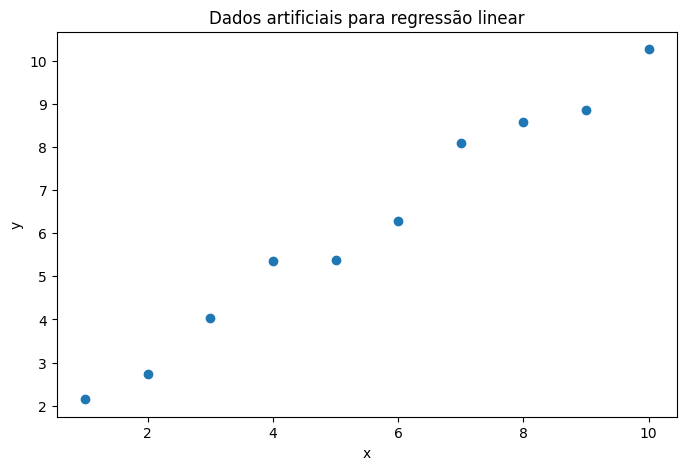

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Gerar dados artificiais
# -----------------------------
np.random.seed(42)

x = np.linspace(1, 10, 10)
ruido = np.random.normal(0, 0.5, size=len(x))

y = 1 + 0.9 * x + ruido

# -----------------------------
# Mostrar os dados
# -----------------------------
print("x =", x)
print("y =", y)

# -----------------------------
# Plot dos dados
# -----------------------------
plt.figure(figsize=(8, 5))
plt.scatter(x, y)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Dados artificiais para regressão linear")

plt.show()

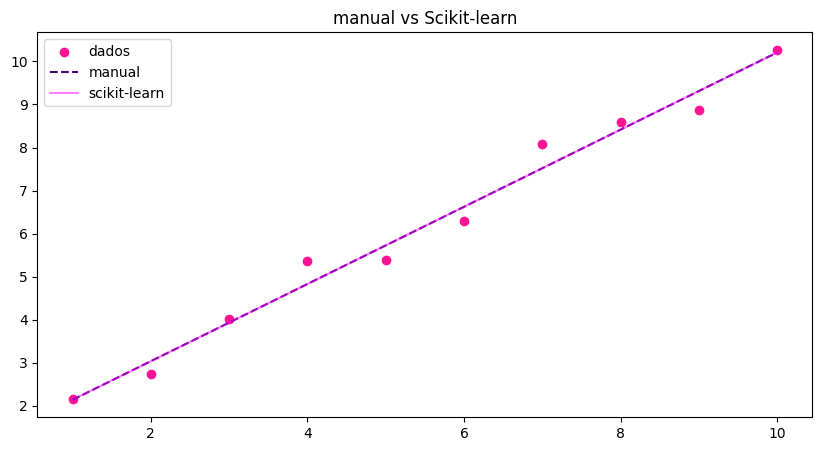

 com o manual: Intercepto (b0) = 1.2430, Inclinação (b1) = 0.8965
 com o sklearn: Intercepto (b0) = 1.2430, Inclinação (b1) = 0.8965


In [30]:
#codigo referente ao exercicio 1

#dados
x = np.linspace(1, 10, 10)
y = np.array([2.14835708,  2.73086785,  4.02384427,  5.36151493,  5.38292331,  6.28293152,
              8.08960641,  8.58371736,  8.86526281, 10.27128002])

X_mat = np.column_stack((np.ones(len(x)), x))
#beta = (X^T * X)^-1 * X^T * y
beta = np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T @ y
b0_manual, b1_manual = beta[0], beta[1]

#scikit-learn-----------------------------------------------------
x_sk = x.reshape(-1, 1)
model = LinearRegression()
model.fit(x_sk, y)

b0_sklearn = model.intercept_
b1_sklearn = model.coef_[0]

#plotando o grafico---------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.scatter(x, y, color='deeppink', label='dados')
plt.plot(x, b0_manual + b1_manual * x, color='indigo', linestyle='--', label='manual')
plt.plot(x, model.predict(x_sk), color='magenta', alpha=0.5, label='scikit-learn')
plt.legend()
plt.title("manual vs Scikit-learn")
plt.show()

#aqui acontece a comparação manual
print("============================================================================")
print(f" com o manual: Intercepto (b0) = {b0_manual:.4f}, Inclinação (b1) = {b1_manual:.4f}")
print(f" com o sklearn: Intercepto (b0) = {b0_sklearn:.4f}, Inclinação (b1) = {b1_sklearn:.4f}")
print("============================================================================")

2 - Considere os dados concrete_data.csv e ajuste um modelo de regressão usando a descida do gradiente.

R2 Score: 0.6249


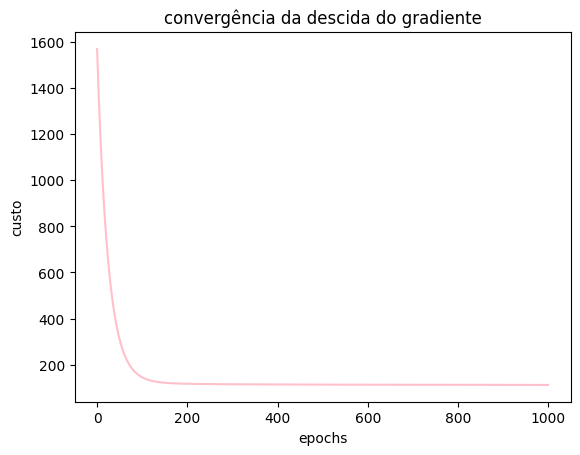

In [56]:
#codigo referente ao exercicio 2

#implementaçao manual da descida do gradiente--------------------------
def fit_regression(X, y, lr=0.01, epochs=1000):
    n_samples, n_features = X.shape
    weights = np.zeros((n_features, 1))
    bias = 0
    c_historico = []

    for _ in range(epochs):
        y_pred = np.dot(X, weights) + bias

        erro = y_pred - y
        custo = np.mean(erro**2)
        c_historico.append(custo)

        dw = (2 / n_samples) * np.dot(X.T, erro)
        db = (2 / n_samples) * np.sum(erro)

        weights -= lr * dw
        bias -= lr * db
    return weights, bias, c_historico

#caminho para a base concrete_data pelo drive-------------------------------------------------
file_path= "/content/drive/MyDrive/Aprendizado_de_maquina_exercicios/concrete_data.csv"
data = pd.read_csv(file_path)
#remove as linhas vazias
data = data.dropna()

#dados
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values # NÃO use LabelEncoder aqui para o concreto!

#normalizaçao
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_treino, X_teste, y_treino, y_teste = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
y_treino = y_treino.reshape(-1, 1)

#treinamento
num_epochs = 1000
w, b, historico = fit_regression(X_treino, y_treino, lr=0.01, epochs=num_epochs)

y_pred_test = np.dot(X_teste, w) + b
print(f"R2 Score: {r2_score(y_teste, y_pred_test):.4f}")

#plotando o grafico---------------------------------------------------------
plt.plot(range(num_epochs), historico, color='pink')
plt.xlabel("epochs")
plt.ylabel("custo")
plt.title("convergência da descida do gradiente")
plt.show()

3 - Faça a classificação da base de vertebralcolumn-2C.csv usando regressão logística implementando a descida do gradiente e compare com o uso do scikit-learn.

In [50]:
#codigo referente ao exercicio 3

#implementaçao manual da descida do gradiente--------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def fit_logistic(X, y, lr=0.1, epochs=1000):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0

    for _ in range(epochs):
        model = np.dot(X, weights) + bias
        predictions = sigmoid(model)

        dw = (1 / n_samples) * np.dot(X.T, (predictions - y))
        db = (1 / n_samples) * np.sum(predictions - y)

        weights -= lr * dw
        bias -= lr * db

    return weights, bias


#caminho para a base vertebralcolumn-2C pelo drive-------------------------------------------------
file_path= "/content/drive/MyDrive/Aprendizado_de_maquina_exercicios/vertebralcolumn-2C.csv"
data = pd.read_csv(file_path)
#remove as linhas vazias
data = data.dropna()

#dados
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

le = LabelEncoder()
y = le.fit_transform(y)

#normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

w_manual, b_manual = fit_logistic(X_train, y_train)
y_pred_manual_prob = sigmoid(np.dot(X_test, w_manual) + b_manual)
y_pred_manual = [1 if i > 0.5 else 0 for i in y_pred_manual_prob]

#implimentaçao do scikit-learn
model_sk = LogisticRegression()
model_sk.fit(X_train, y_train)
y_pred_sk = model_sk.predict(X_test)

#printando os valores-------------------------------------
print("============================================================================")
print(f"acurácia feita manualmente: {accuracy_score(y_test, y_pred_manual):.4f}")
print(f"acurácia feita pelo scikit-learn: {accuracy_score(y_test, y_pred_sk):.4f}")
print("============================================================================")

acurácia feita manualmente: 0.8871
acurácia feita pelo scikit-learn: 0.8710
